# Quickstart: Online Conformal Prediction

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/egonmedhatten/online-cp/HEAD?urlpath=%2Fdoc%2Ftree%2Fnotebooks%2Fquickstart.ipynb)

Every model is wrong sometimes. But what if you could **bound how often** — with a mathematical guarantee?

Conformal prediction gives you prediction intervals (regression) or prediction sets (classification) that satisfy:

$$\mathbb{P}(y_{\text{new}} \in \Gamma^\varepsilon) \geq 1 - \varepsilon$$

No distributional assumptions. No asymptotic arguments. Valid in finite samples.

Let's see it in action.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

## Regression: California Housing

We predict median house values from census features. The data is randomly permuted to ensure exchangeability — the key assumption that makes conformal prediction work.

In [2]:
from online_cp import ConformalRidgeRegressor, ErrorRate, IntervalWidth
from online_cp.evaluate import progressive_val
from online_cp.plotting import plot_coverage, plot_intervals

# Load and permute data
data = fetch_california_housing()
rng = np.random.default_rng(42)
perm = rng.permutation(len(data.target))
X, y = data.data[perm[:500]], data.target[perm[:500]]  # 500 samples for speed

# Create model and learn an initial training set
model = ConformalRidgeRegressor(a=1.0)
model.learn_initial_training_set(X[:50], y[:50])

# Evaluate: test-then-train on the remaining 450 points
metric = ErrorRate() + IntervalWidth()
progressive_val(model, X[50:], y[50:], epsilon=0.1, metric=metric)

print(metric)

ErrorRate: 0.1356
IntervalWidth: 2.2605


The error rate is at most $\varepsilon = 0.1$ — the guarantee holds. Let's visualise it:

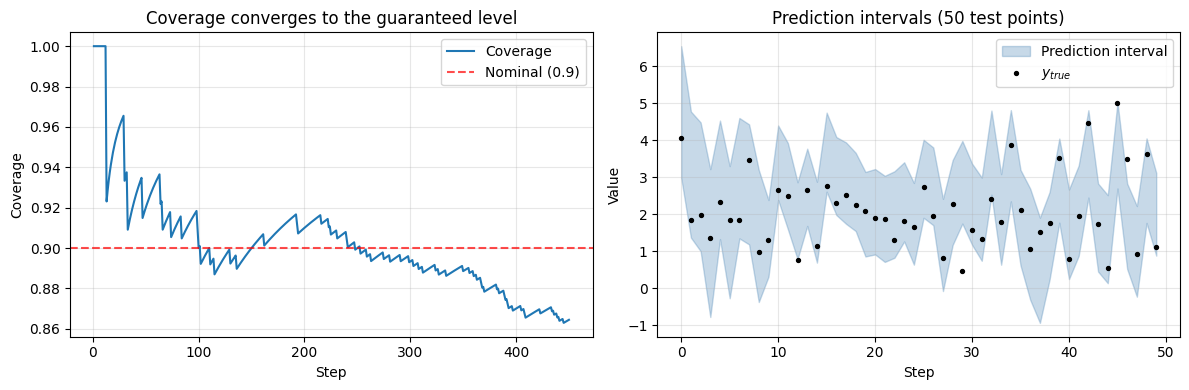

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: the coverage guarantee in action
plot_coverage(metric["ErrorRate"], nominal=0.9, ax=axes[0])
axes[0].set_title("Coverage converges to the guaranteed level")

# Right: what the intervals look like
# Collect intervals for a subset
model2 = ConformalRidgeRegressor(a=1.0)
model2.learn_initial_training_set(X[:50], y[:50])
intervals = []
for i in range(50, 100):
    intervals.append(model2.predict(X[i], epsilon=0.1))
    model2.learn_one(X[i], y[i])

plot_intervals(y[50:100], intervals, ax=axes[1])
axes[1].set_title("Prediction intervals (50 test points)")
plt.tight_layout()
plt.show()

## Classification: Wine

For classification, conformal prediction produces **prediction sets** — subsets of labels guaranteed to contain the true class. A singleton set means high confidence; multiple labels mean uncertainty.

In [4]:
from online_cp import ConformalNearestNeighboursClassifier, SetSize
from online_cp.plotting import plot_set_sizes

# Load and permute
wine = load_wine()
perm_w = rng.permutation(len(wine.target))
X_w, y_w = wine.data[perm_w], wine.target[perm_w]
label_space = np.unique(y_w)

# Conformal kNN classifier
clf = ConformalNearestNeighboursClassifier(k=5, label_space=label_space)
clf.learn_initial_training_set(X_w[:30], y_w[:30])

# Evaluate
metric_cls = ErrorRate() + SetSize()
progressive_val(clf, X_w[30:], y_w[30:], epsilon=0.1, metric=metric_cls)

print(metric_cls)
print(f"\nFraction of singletons (confident): "
      f"{np.mean(np.array(metric_cls['SetSize'].values) == 1):.0%}")

ErrorRate: 0.0743
SetSize: 1.5473

Fraction of singletons (confident): 49%


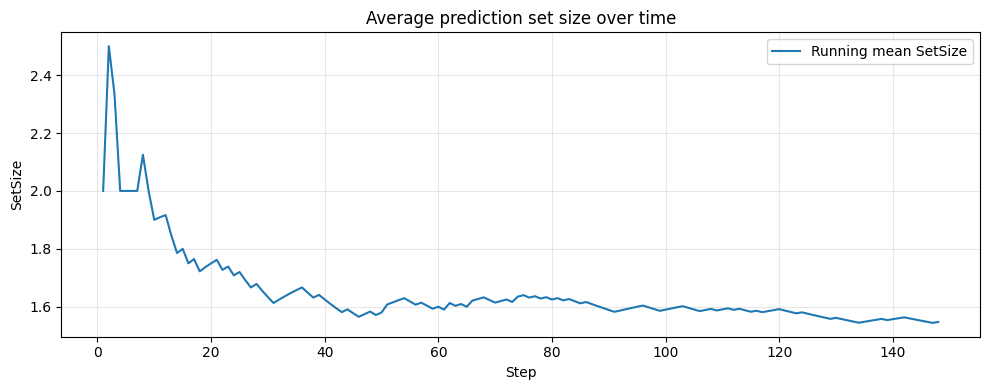

In [5]:
plot_set_sizes(metric_cls["SetSize"])
plt.title("Average prediction set size over time")
plt.tight_layout()
plt.show()

## Multi-level predictions

Like a zoom lens: request intervals at multiple confidence levels in a single call.

In [6]:
# Predict at multiple significance levels simultaneously
model3 = ConformalRidgeRegressor(a=1.0)
model3.learn_initial_training_set(X[:100], y[:100])

result = model3.predict(X[100], epsilon=[0.01, 0.05, 0.1, 0.2])

print(f"True value: {y[100]:.2f}\n")
for eps, interval in result:
    hit = "\u2713" if y[100] in interval else "\u2717"
    print(f"  \u03b5={eps:.2f}: [{interval.lower:.2f}, {interval.upper:.2f}]  "
          f"width={interval.width():.2f}  {hit}")

True value: 1.11

  ε=0.01: [-inf, inf]  width=inf  ✓
  ε=0.05: [-1.40, 2.77]  width=4.16  ✓
  ε=0.10: [-0.74, 1.56]  width=2.30  ✓
  ε=0.20: [-0.48, 1.32]  width=1.81  ✓


## Calibrated Probabilities: Venn-Abers

Sometimes you want calibrated probabilities instead of a prediction set. The **Venn-Abers predictor** produces a multiprobability pair $(p^0, p^1)$ — two calibrated probabilities of $P(y=1)$ under the two possible label hypotheses. This pair IS the prediction; it is automatically well-calibrated with no post-hoc adjustments.

In [ ]:
from online_cp import VennAbersPredictor
from sklearn.datasets import load_breast_cancer

# Binary classification task
bc = load_breast_cancer()
perm_bc = rng.permutation(len(bc.target))
X_bc, y_bc = bc.data[perm_bc], bc.target[perm_bc]

# Full online Venn-Abers predictor with ridge scoring
vap = VennAbersPredictor(scorer="ridge", a=1.0)
vap.learn_initial_training_set(X_bc[:50], y_bc[:50])

# Stream: predict then learn — the prediction is the pair (p0, p1)
print("step  true   (p0,    p1)")
print("-" * 32)
for i in range(50, 60):
    pred = vap.predict(X_bc[i])
    print(f"  {i-50:2d}    {y_bc[i]}   ({pred.p0:.3f}, {pred.p1:.3f})")
    vap.learn_one(X_bc[i], y_bc[i])

# To merge into a single probability for decision-making:
# log_loss_point(pred.p0, pred.p1) or brier_point(pred.p0, pred.p1)

step  true   (p0,    p1)
--------------------------------


   0    1   (0.833, 1.000)
   1    1   (0.750, 1.000)
   2    1   (0.000, 1.000)
   3    1   (0.000, 1.000)
   4    1   (0.917, 1.000)
   5    1   (0.000, 0.750)
   6    1   (0.944, 1.000)
   7    1   (0.833, 1.000)
   8    1   (0.941, 1.000)
   9    0   (0.000, 0.167)


## Key takeaways

- **Guaranteed coverage** — $\mathbb{P}(y \in \Gamma^\varepsilon) \geq 1 - \varepsilon$, no matter the data distribution
- **Online** — predictions improve as the model sees more data, one example at a time
- **No tuning** — the coverage guarantee holds regardless of hyperparameter choices
- **Works for any task** — regression (intervals), classification (sets), and calibrated probabilities (Venn-Abers)

## Where to go next

The full [tutorial](tutorial.ipynb) covers:

| Topic | Question it answers |
|-------|--------------------|
| **Regression deep-dive** | Ridge, Kernel Ridge, and Lasso — when to use which? |
| **Classification** | KNN vs SVM, prediction set interpretation |
| **Venn-Abers** | How to get calibrated probabilities without data splitting? |
| **Mondrian CP** | How to guarantee fairness across groups? |
| **Predictive Systems** | What does the full predictive distribution look like? |
| **Martingales** | How to detect when your data distribution changes? |
| **Evaluation** | Streaming metrics, plotting, conditional learning |